# Atrous correlation em imagens RGB

Universidade Federal da Paraíba- Centro de informática

Trabalho da disciplina de Introdução ao Processamento Digital de Imagens

Professor: Leonardo Vidal Batista

Aluno: Caio Vitor Melo de Santana

Objetivo: Desenvolver um sistema de processamento de imagem para manipulação de
arquivos RGB e aplicação de operadores espaciais utilizando correlação dilatada.

## Introdução

O Processamento Digital de Imagens (PDI) é uma área da computação que estuda técnicas para análise, manipulação e interpretação de imagens digitais. Operadores espaciais, como correlação e convolução, são amplamente utilizados para tarefas como suavização, detecção de bordas e extração de características. Neste trabalho, propõe-se a implementação manual de um sistema de correlação dilatada aplicado a imagens RGB, com o objetivo de compreender de forma prática o funcionamento desses operadores. 

## Fundamentação Teórica breve

### Correlação vs Convolução

A correlação (no caso a não normalizada, que é a utilizada nesse projeto e na maioria dos trabalhos relacionados a PDI) é uma operação entre um sinal s e uma mascara h em que cada amostra é o produto interno entre s e h em cada posição da máscara em relação ao sinal

Convolução é um termo muito utilizado e geralmente as pessoas estão falando da correlação quando utilizam ele, mas convolução propriamente dita é correlação só que com a máscara rebatida (espelhada horizontalmente e verticalmente)


### Correlação dilatada

A correlação dilatada é a correlação só que com espaços r (configuraveis) entre os elementos da mascara, isso é bom porque permite você alcançar mais pixels, a mascara continua sendo 3x3 mas o campo receptivo é maior sem precisar aumentar o tamanho da mascara e consequentemente o custo computacional

Existem 3 tipos de correlação dilatada a que usa R fixo (utilizada na atual implementação desse trabalho) com R progressivo (mudando o r de acordo com a etapa do processamento da imagem) e ASPP (Atrous Spatial Pyramid Pooling) que usa vários valores de r em paralelo, extrai as informações e combina os resultados

### Conceito de stride (passo)

O stride é a quantidade de pixels que a mascara anda a cada aplicação, um stride maior gera menos sobreposição e uma saida menor

### Funções de ativação

Após a aplicação da correlação dilatada pode-se aplicar uma função de ativação em cima do resultado, nesse trabalho foram implementadas 2 funções de ativação por enquanto (na prática só 1), a identidade, que mantém os valores originais e a ReLU que substitui valores negativos por zero

No contexto de PDI a ReLU pode ser util pra descartar respostas negativas pra enfatizar apenas correlações positivas por exemplo em um detector de padrões como na aplicação de filtro casado

--------------------------------

### Formulas

Correlação não normalizada
$$
Y(i,j) =
\sum_{m=0}^{K-1}
\sum_{n=0}^{K-1}
I(i+m, j+n)\, H(m,n)
$$
$I$ é a imagem

$H$ é a máscara

$K$ é o tamanho da máscara

$K$ é o tamanho do kernel


-----------------------------------------------------------------------------------------

Correlação normalizada
$$
Y(i,j) =
\frac{
\sum_{m=0}^{K-1} \sum_{n=0}^{K-1}
\left[I(i+m, j+n) - \mu_{I_{ij}}\right]
\left[H(m,n) - \mu_H\right]
}{
\sqrt{
\sum_{m=0}^{K-1} \sum_{n=0}^{K-1}
\left[I(i+m, j+n) - \mu_{I_{ij}}\right]^2
}
\sqrt{
\sum_{m=0}^{K-1} \sum_{n=0}^{K-1}
\left[H(m,n) - \mu_H\right]^2
}
}
$$

$\mu_{I_{ij}}$ é a média da janela da imagem

$\mu_H$ é a média da máscara

-------------------------------------------------

Correlação dilatada
$$
Y(i,j) =
\sum_{m=0}^{K-1}
\sum_{n=0}^{K-1}
I(i + r m,\; j + r n)\, H(m,n)
$$
$r$ é a taxa de dilatação

$r = 1$ → correlação comum

$r > 1$ → aumenta o campo receptivo

----------------------------------------------

Campo receptivo efetivo na dilatação
$$
K_{\text{efetivo}} =
K + (K - 1)(r - 1)
$$


----------------------------------------

##### Imports

In [19]:
#bibliotecas
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from funcoesaux import *
import json

#minhas implementações
from correlacao import correlacao
from filtros import *
from io_imagem import *

#### Carregamento da Imagem

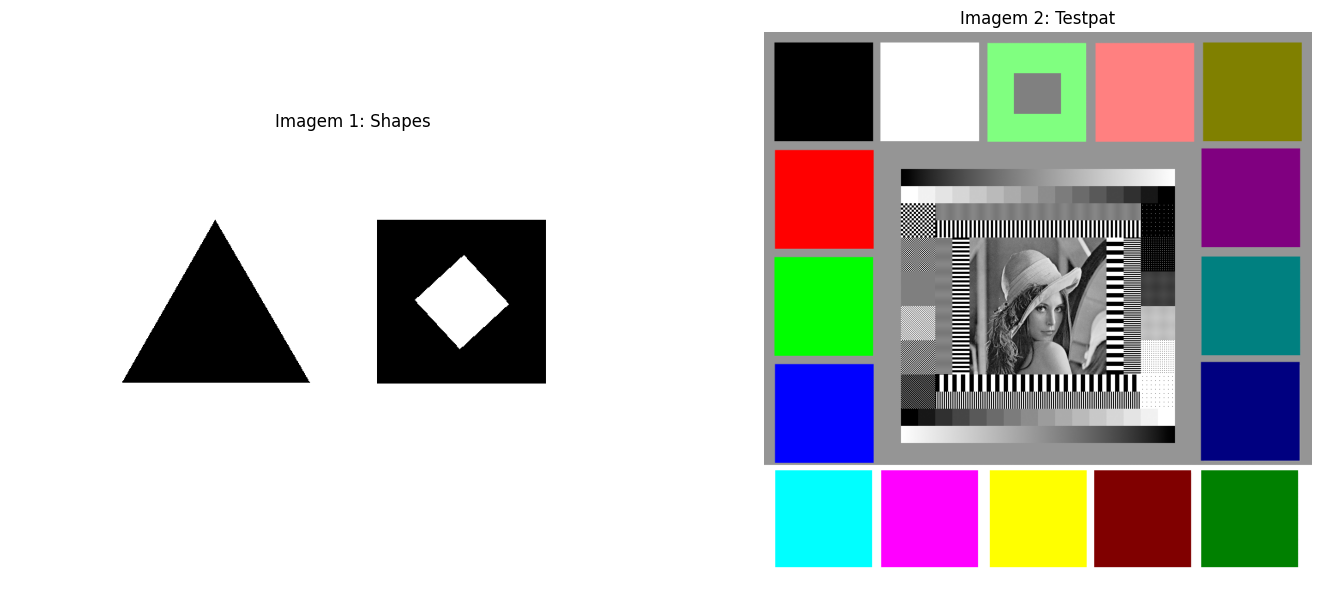

In [20]:
img1 = abrir_imagem("Imagens/Shapes.png")
img2 = abrir_imagem("Imagens/testpat.1k.color2.tif")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img1.astype(np.uint8))
axes[0].set_title("Imagem 1: Shapes")
axes[0].axis("off")

axes[1].imshow(img2.astype(np.uint8))
axes[1].set_title("Imagem 2: Testpat")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### Carregamento da Configuração (JSON)

In [21]:
with open("config_filtros.json", "r", encoding="utf-8") as f:
    config = json.load(f)

---
## Aplicação dos Filtros

Todos os filtros são aplicados com os parâmetros padrão do JSON: r=1 e stride=1 e a função de ativação é a identidade

### Filtro Gaussiano 5x5

O filtro Gaussiano é um filtro que suaviza a imagem, os pesos seguem uma distribuição gaussiana, dando mais importância ao pixel central, no padrão os coeficientes somam pra 1, se passar de 1 o brilho aumenta, se ficar abaixo o brilho diminui

Máscara Gaussiano 5x5:
[[0.0039 0.0156 0.0234 0.0156 0.0039]
 [0.0156 0.0625 0.0938 0.0625 0.0156]
 [0.0234 0.0938 0.1406 0.0938 0.0234]
 [0.0156 0.0625 0.0938 0.0625 0.0156]
 [0.0039 0.0156 0.0234 0.0156 0.0039]]


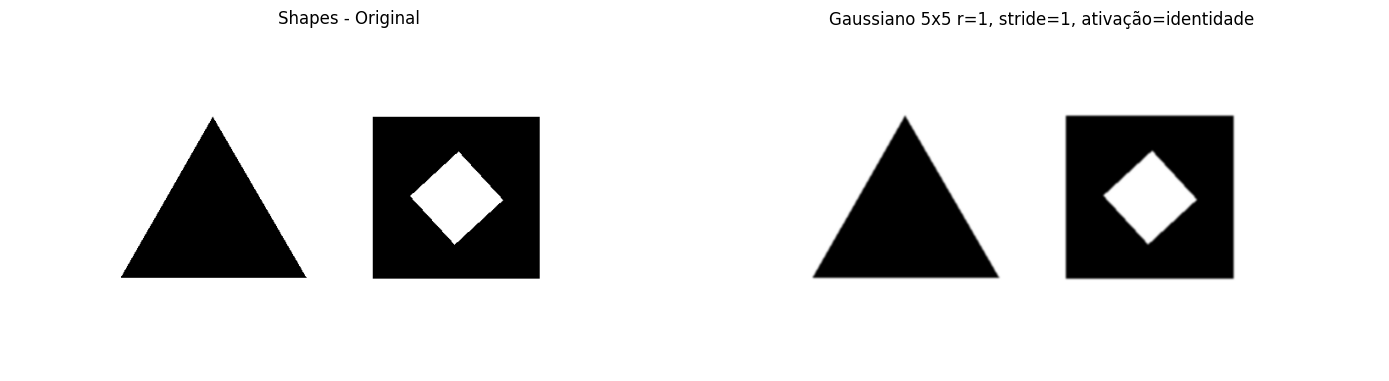

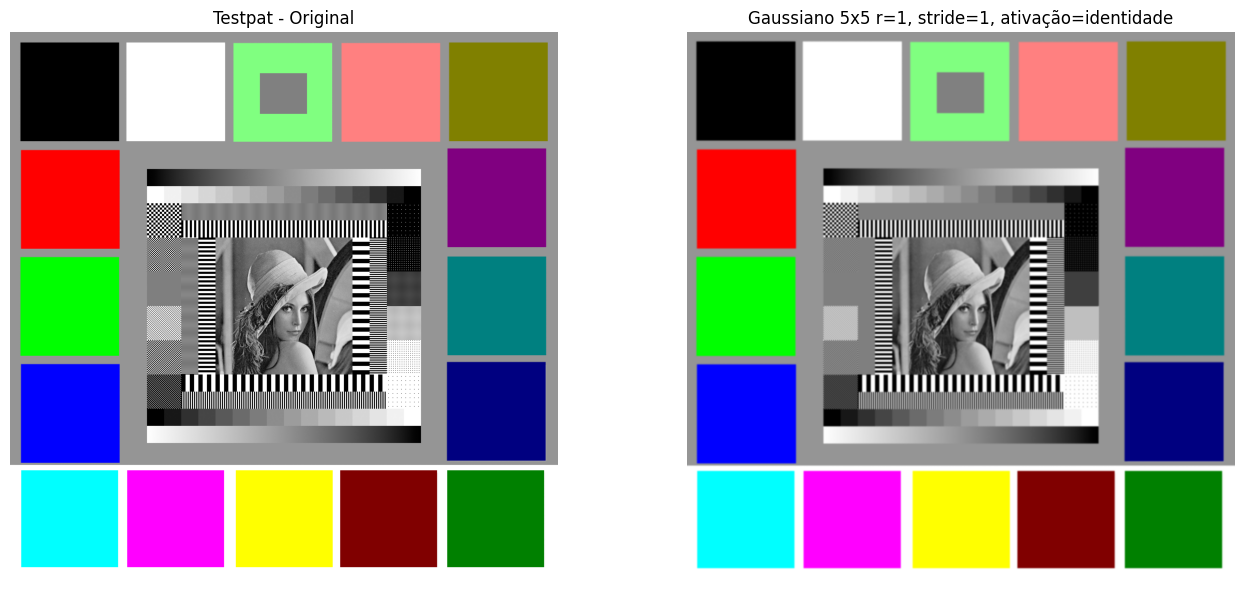

In [22]:
#mostrar a mascara do filtro gaussiano, com precisão 4 digitos
mascara_gaussiano = gaussiano_5x5()
print("Máscara Gaussiano 5x5:")
print(np.round(mascara_gaussiano, 4))

#aplicação do filtro e exibição das imagens
gauss_img1 = aplicar_e_exibir(img1, mascara_gaussiano, "Gaussiano 5x5", "Shapes")

gauss_img2 = aplicar_e_exibir(img2, mascara_gaussiano, "Gaussiano 5x5", "Testpat")

### Filtro Box 1x10

O filtro Box 1x10 realiza uma média no eixo horizontal, isso causa um borramento nesse eixo

Máscara Box 1x10:
[[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]]


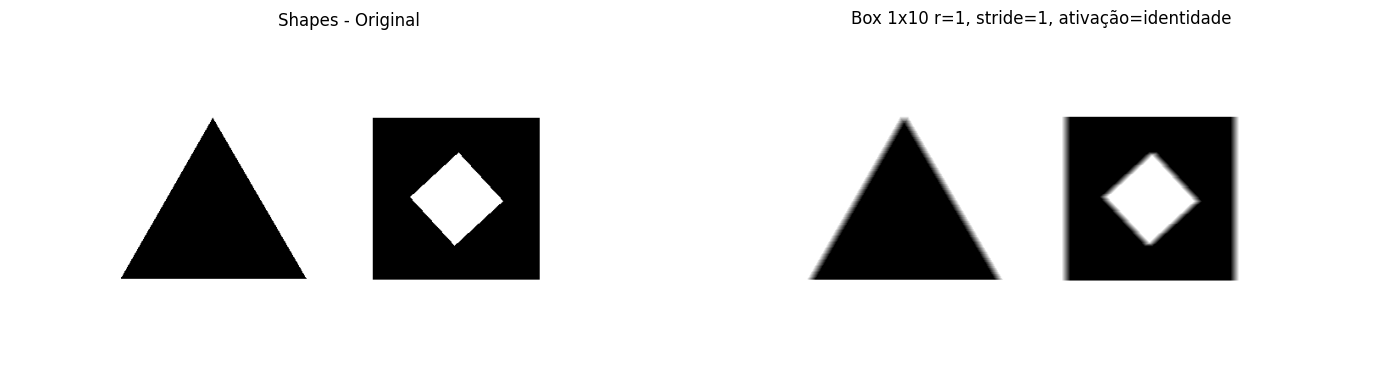

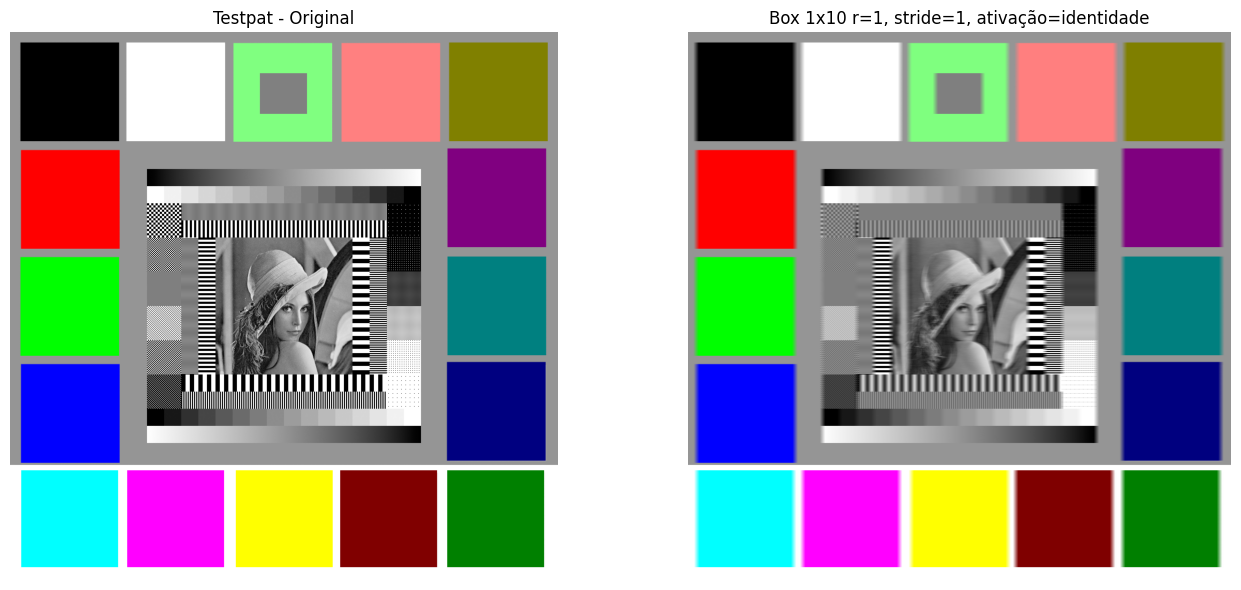

In [23]:
mascara_box_1x10 = box_mascara(1, 10)
print("Máscara Box 1x10:")
print(mascara_box_1x10)

box1x10_img1 = aplicar_e_exibir(img1, mascara_box_1x10, "Box 1x10", "Shapes")
box1x10_img2 = aplicar_e_exibir(img2, mascara_box_1x10, "Box 1x10", "Testpat")

### Filtro Box 10x1

O filtro Box 1x10 realiza uma média no eixo vertical, isso causa um borramento nesse eixo

Máscara Box 10x1:
[[0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]]


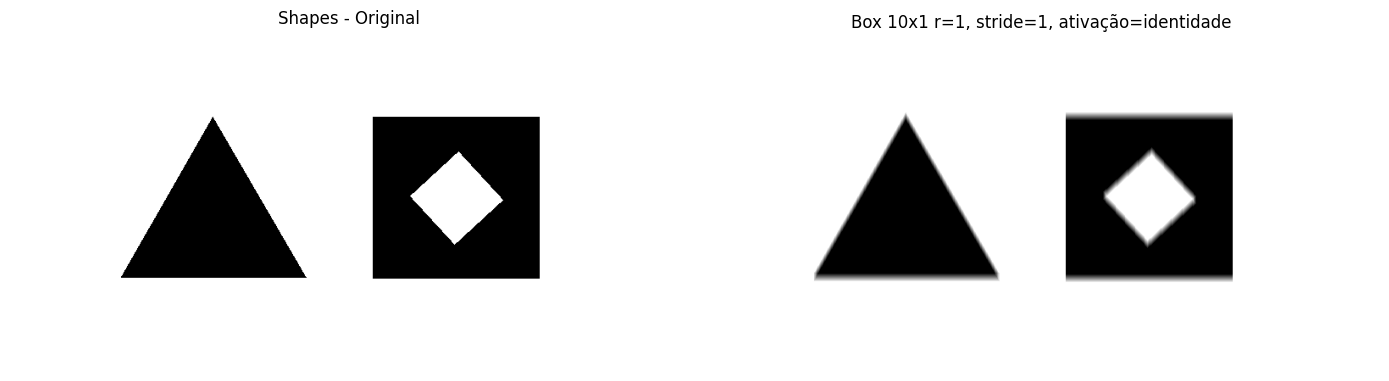

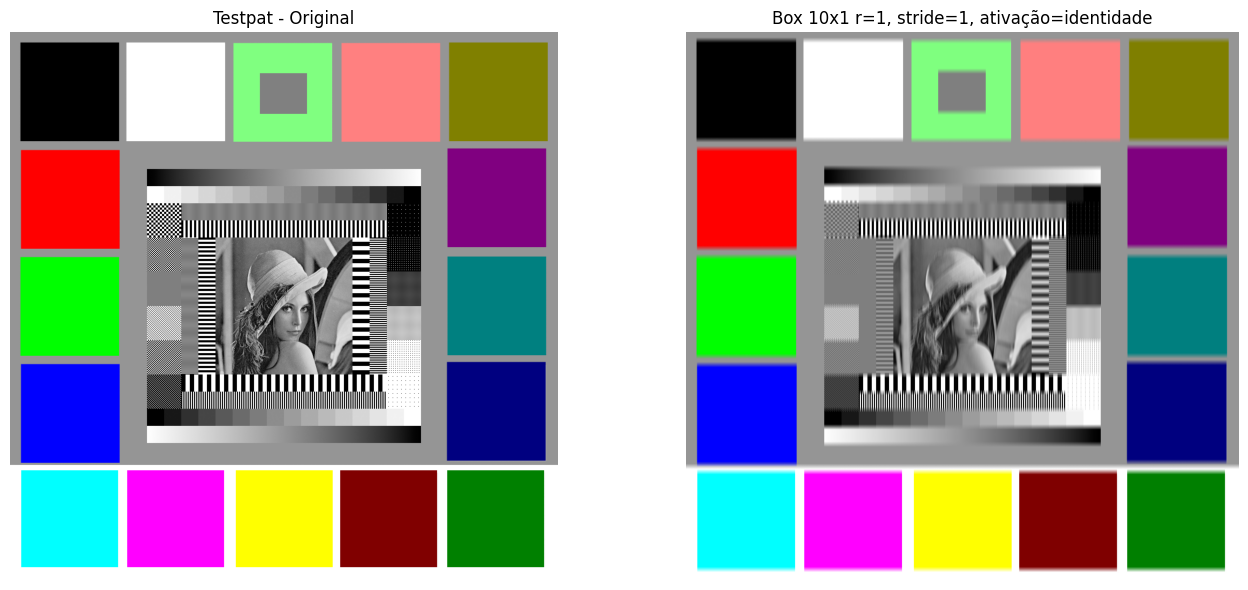

In [24]:
mascara_box_10x1 = box_mascara(10, 1)
print("Máscara Box 10x1:")
print(mascara_box_10x1)

box10x1_img1 = aplicar_e_exibir(img1, mascara_box_10x1, "Box 10x1", "Shapes")
box10x1_img2 = aplicar_e_exibir(img2, mascara_box_10x1, "Box 10x1", "Testpat")

### Filtro Box 10x10

O filtro Box 10x10 realiza uma média em ambos eixos, produz o borramento mais intenso entre os filtros box testados, pois a janela de média é a maior (100 pixels)

Máscara Box 10x10:
[[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
 [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
 [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
 [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
 [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
 [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
 [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
 [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
 [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
 [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]]


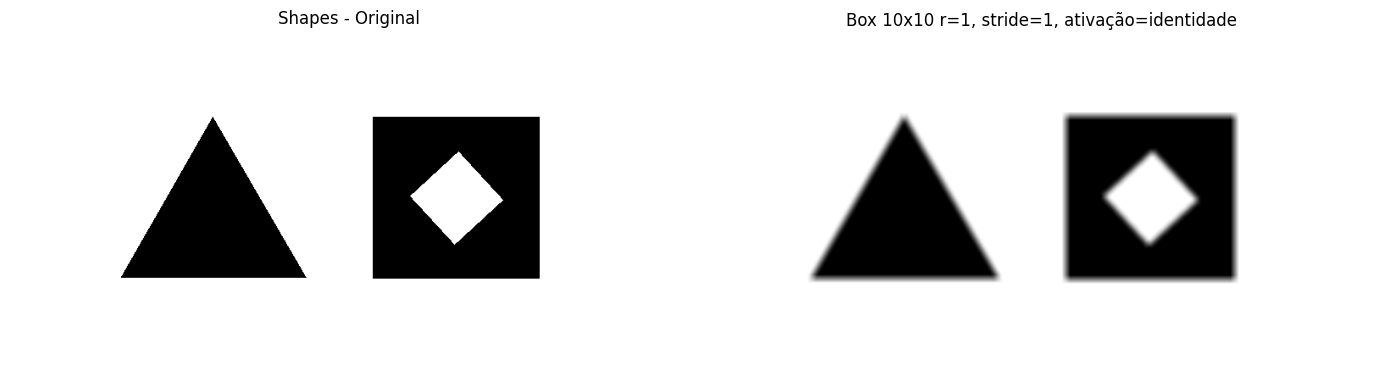

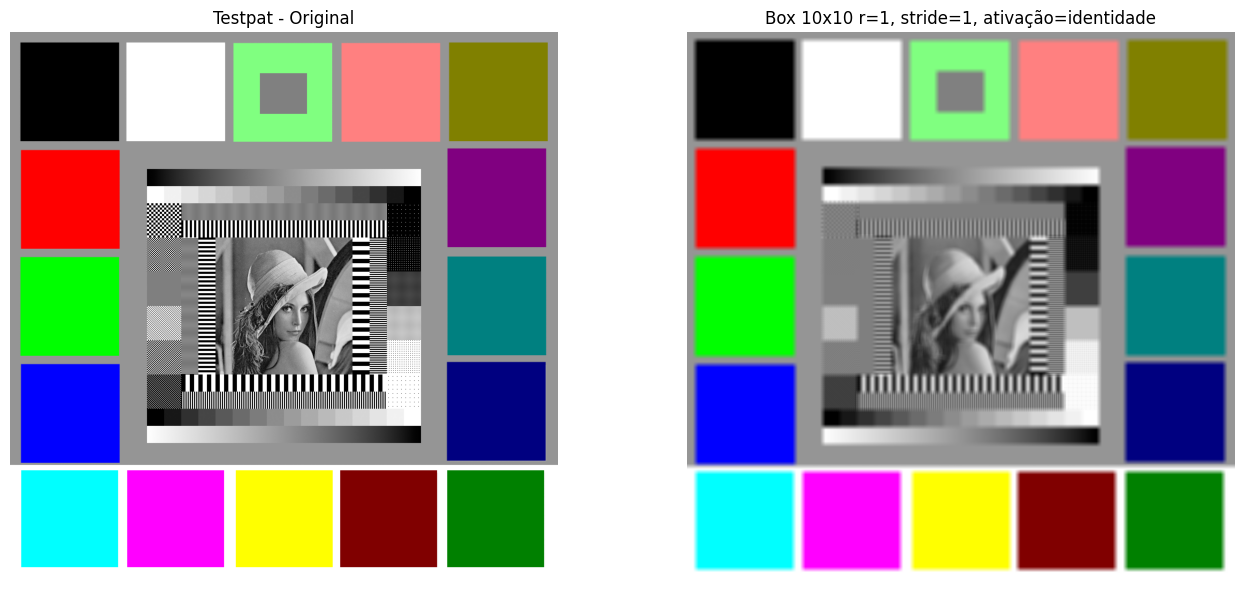

In [25]:
mascara_box_10x10 = box_mascara(10, 10)
print("Máscara Box 10x10:")
print(np.round(mascara_box_10x10, 4))

box10x10_img1 = aplicar_e_exibir(img1, mascara_box_10x10, "Box 10x10", "Shapes")
box10x10_img2 = aplicar_e_exibir(img2, mascara_box_10x10, "Box 10x10", "Testpat")

### Filtro Sobel Horizontal

O filtro Sobel Horizontal detecta bordas horizontais

 Os valores negativos indicam gradiente para cima e positivos para baixo

Aplicamos o valor absoluto (porque em sobel o que importa é a variação não o sinal) do resultado seguido de expansão de histograma (pra aumentar o contraste)

Máscara Sobel Horizontal:
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]


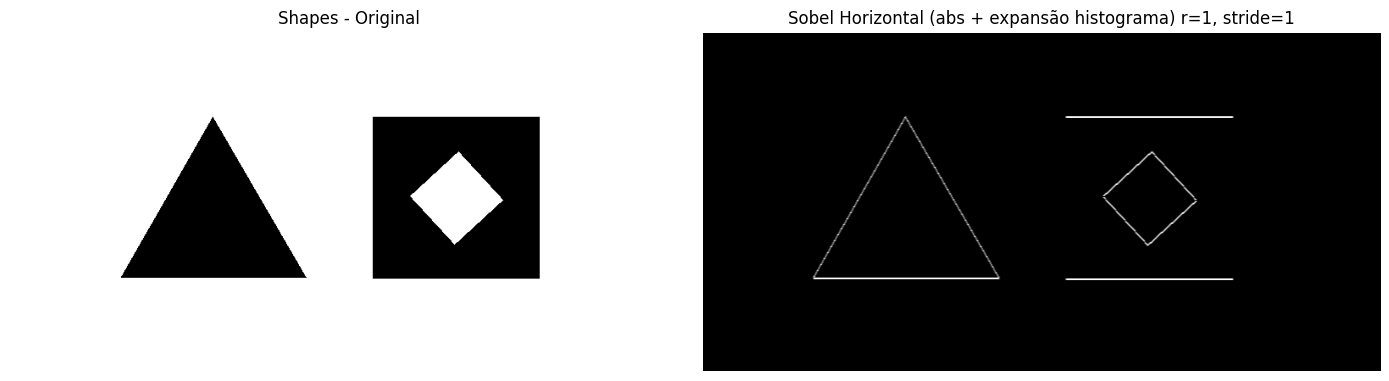

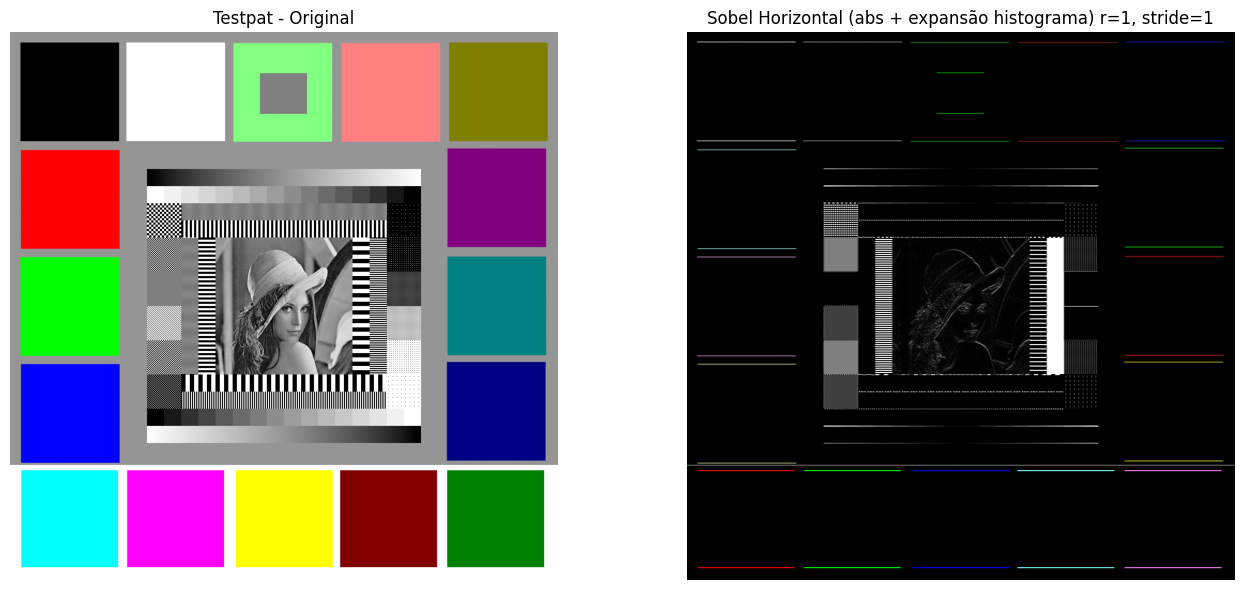

In [26]:
mascara_sobel_h = sobel_horizontal()
print("Máscara Sobel Horizontal:")
print(mascara_sobel_h)

sobel_h_img1 = aplicar_e_exibir(img1, mascara_sobel_h, "Sobel Horizontal", "Shapes", sobel=True)

sobel_h_img2 = aplicar_e_exibir(img2, mascara_sobel_h, "Sobel Horizontal", "Testpat", sobel=True)

### Filtro Sobel Vertical

O filtro Sobel Horizontal detecta bordas horizontais

Os valores negativos indicam gradiente para cima e positivos para baixo

Aplicamos o valor absoluto (porque em sobel o que importa é a variação não o sinal) do resultado seguido de expansão de histograma (pra aumentar o contraste)

Máscara Sobel Vertical:
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]


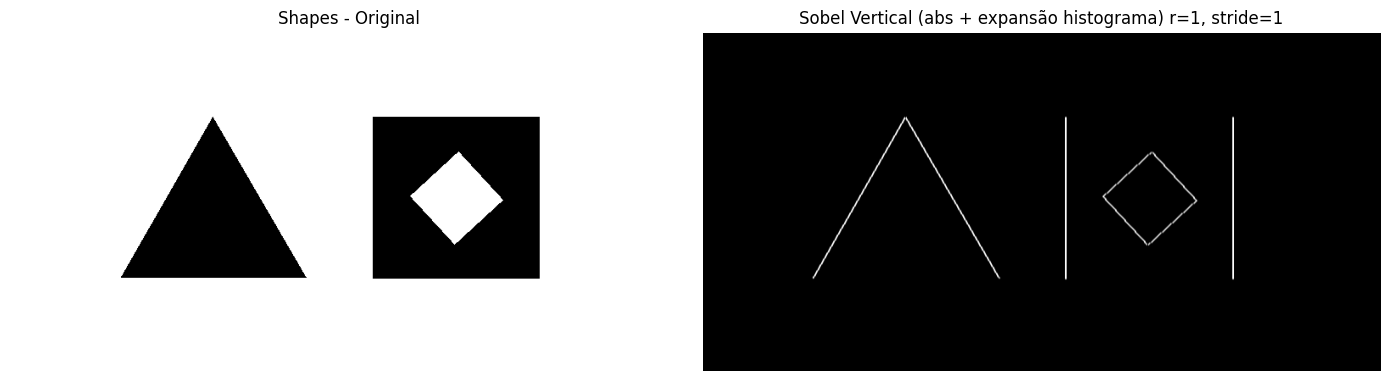

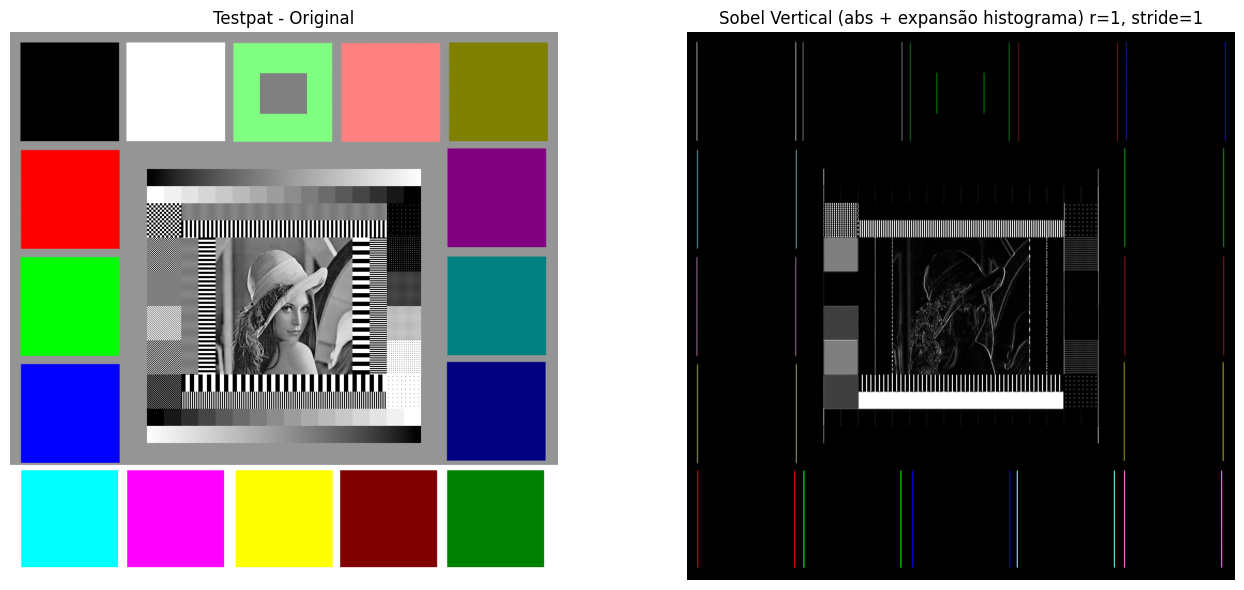

In [27]:
mascara_sobel_v = sobel_vertical()
print("Máscara Sobel Vertical:")
print(mascara_sobel_v)

sobel_v_img1 = aplicar_e_exibir(img1, mascara_sobel_v, "Sobel Vertical", "Shapes", sobel=True)

sobel_v_img2 = aplicar_e_exibir(img2, mascara_sobel_v, "Sobel Vertical", "Testpat", sobel=True)

---
## Análise do Efeito da Taxa de Dilatação (r)

Vamos testar o filtro Gaussiano 5x5 com valores de r de 1 a 5 na Imagem 1:

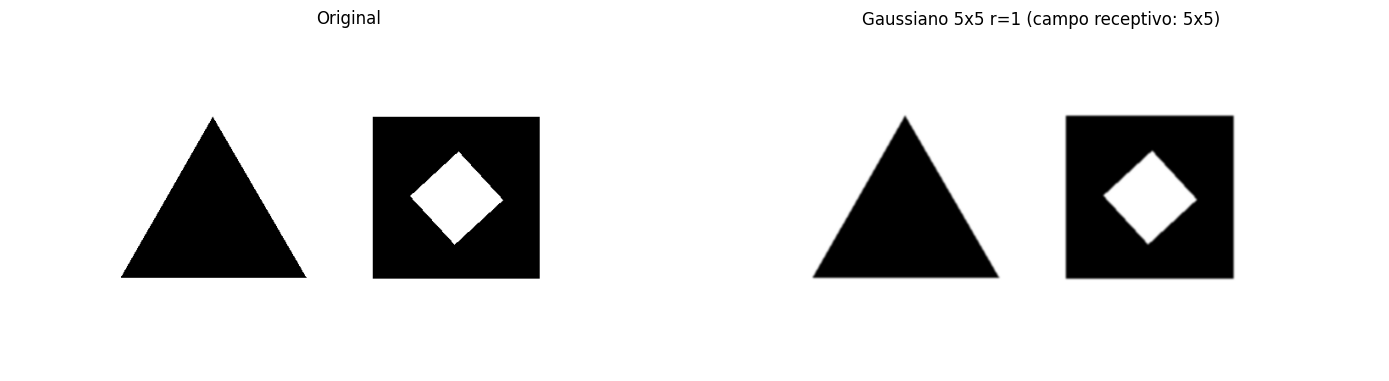

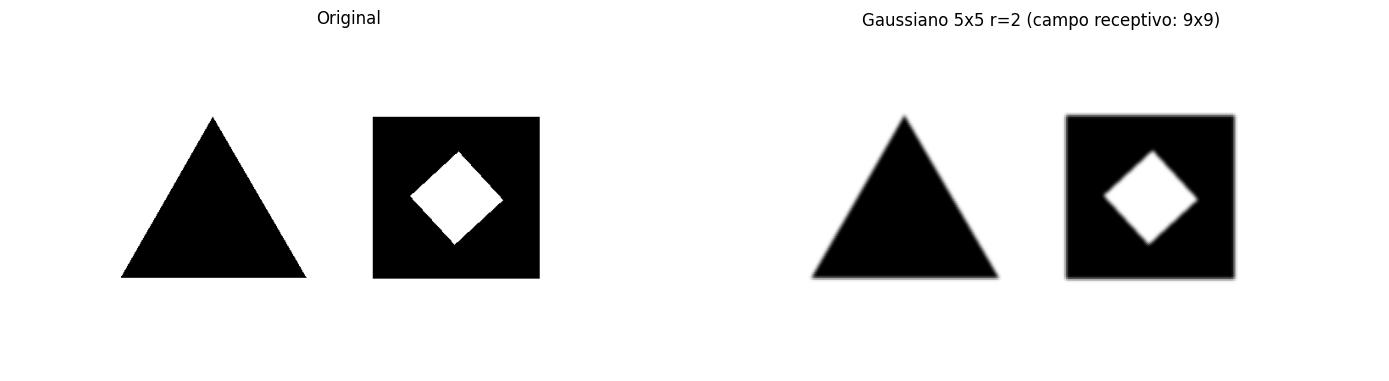

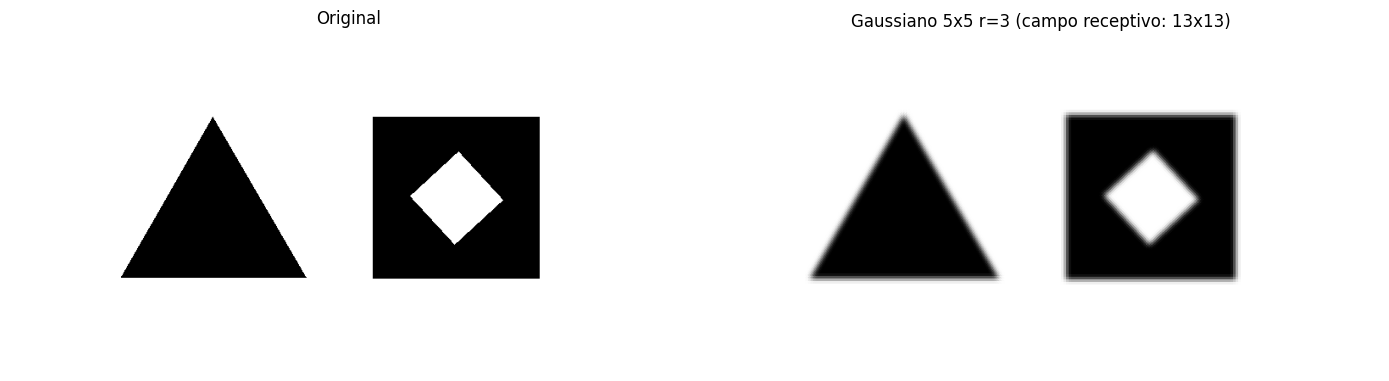

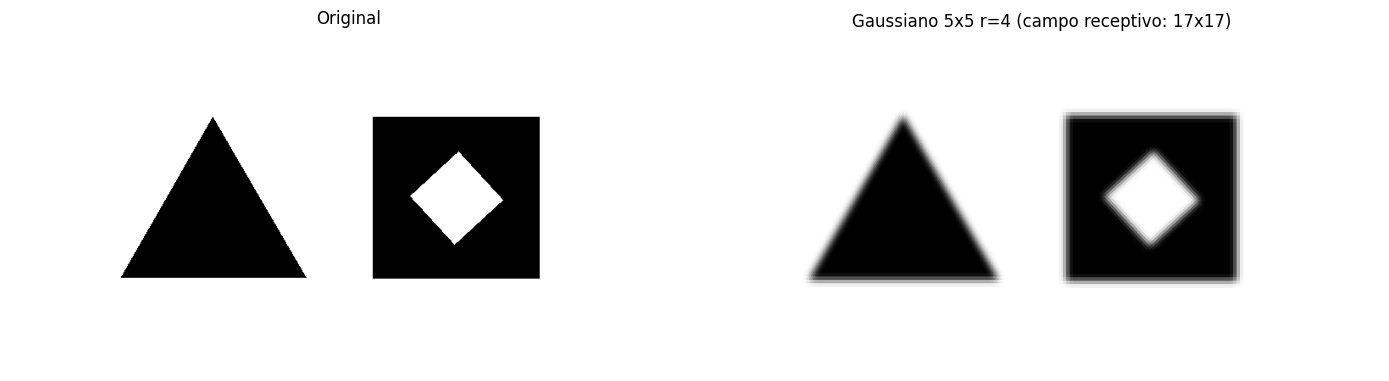

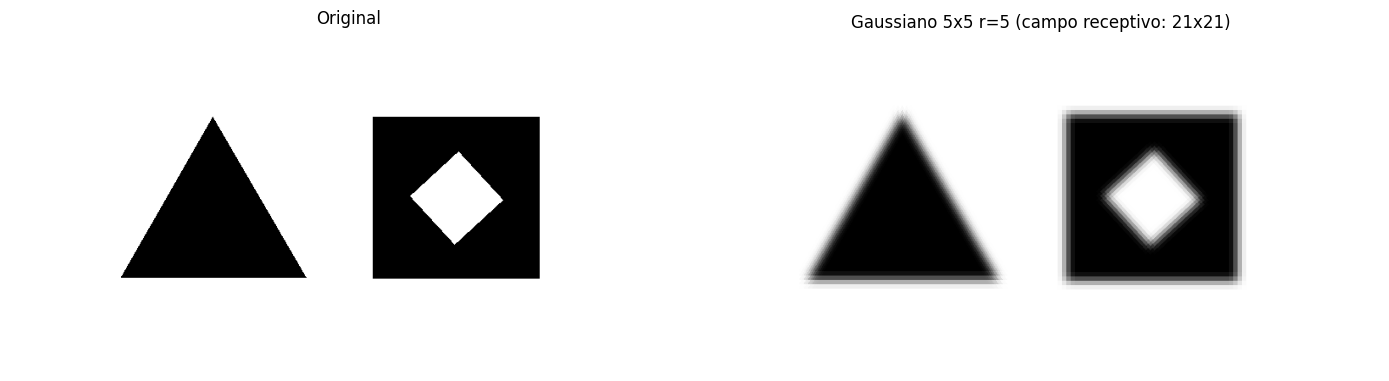

In [28]:
mascara_gaussiano = gaussiano_5x5()
valores_r = [1, 2, 3, 4, 5]

for r_val in valores_r:
    k_efetivo = 5 + (5 - 1) * (r_val - 1)
    
    resultado = correlacao(img1, mascara_gaussiano, stride=1, r=r_val)
    resultado = np.clip(resultado, 0, 255).astype(np.uint8)
    
    exibir_lado_a_lado(img1, resultado,
        titulo_original="Original",
        titulo_resultado=f"Gaussiano 5x5 r={r_val} (campo receptivo: {k_efetivo}x{k_efetivo})"
    )

#### Efeito do r nos filtros Sobel

Vamos observar como a dilatação afeta a detecção de bordas com o Sobel Horizontal:

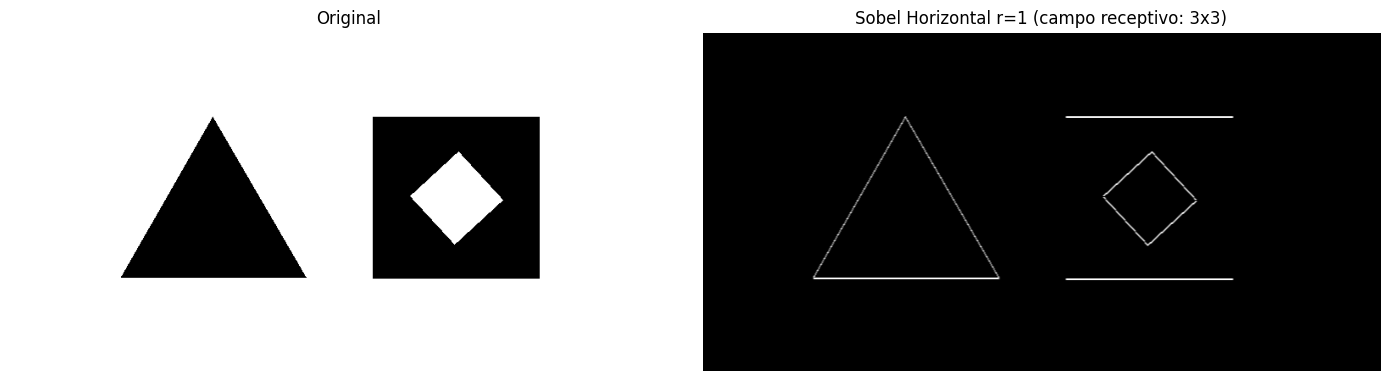

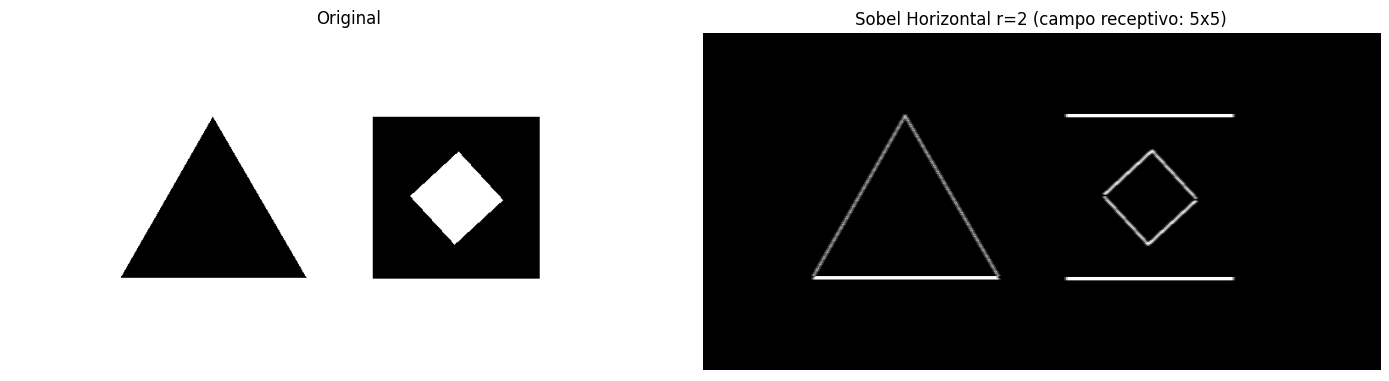

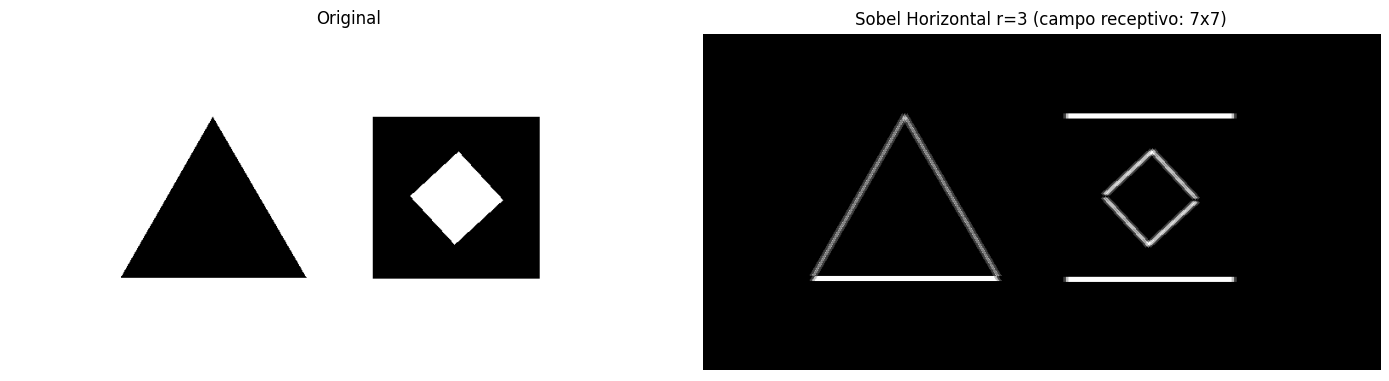

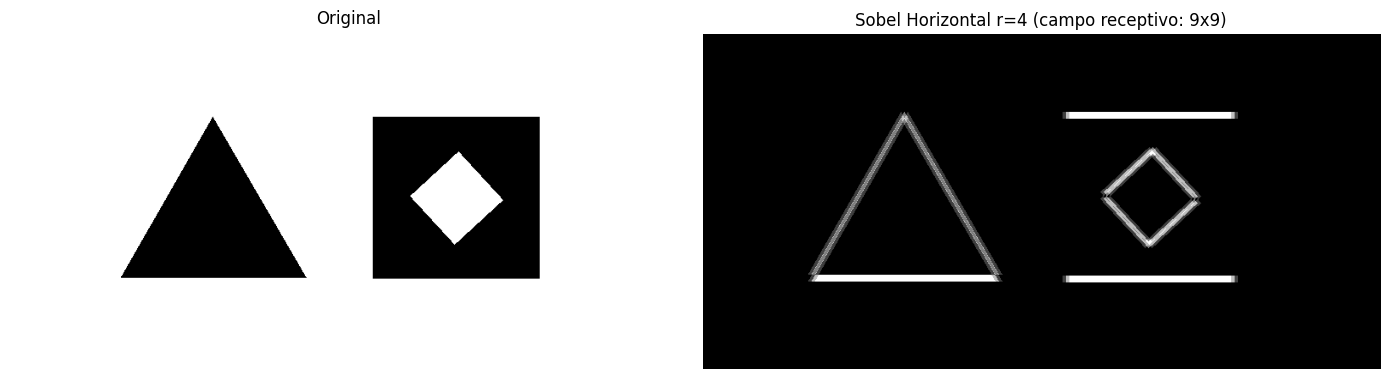

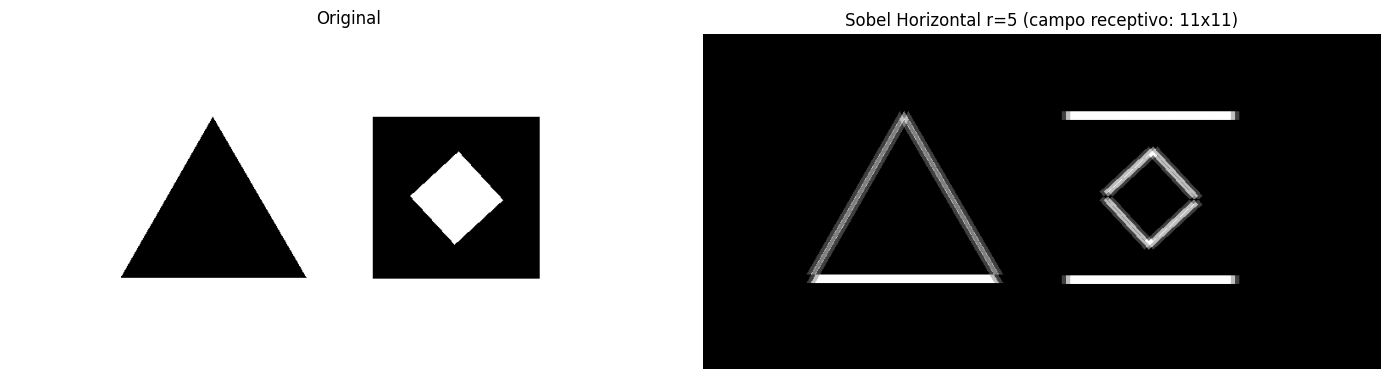

In [29]:
mascara_sh = sobel_horizontal()
valores_r = [1, 2, 3, 4, 5]

for r_val in valores_r:
    k_efetivo = 3 + (3 - 1) * (r_val - 1)
    
    resultado = correlacao(img1, mascara_sh, stride=1, r=r_val)
    resultado = processar_sobel(resultado)
    
    exibir_lado_a_lado(img1, resultado,
        titulo_original="Original",
        titulo_resultado=f"Sobel Horizontal r={r_val} (campo receptivo: {k_efetivo}x{k_efetivo})"
    )

---
## Análise do Efeito do Stride (Passo)

Vamos testar o Gaussiano 5x5 com stride de 1 a 5:

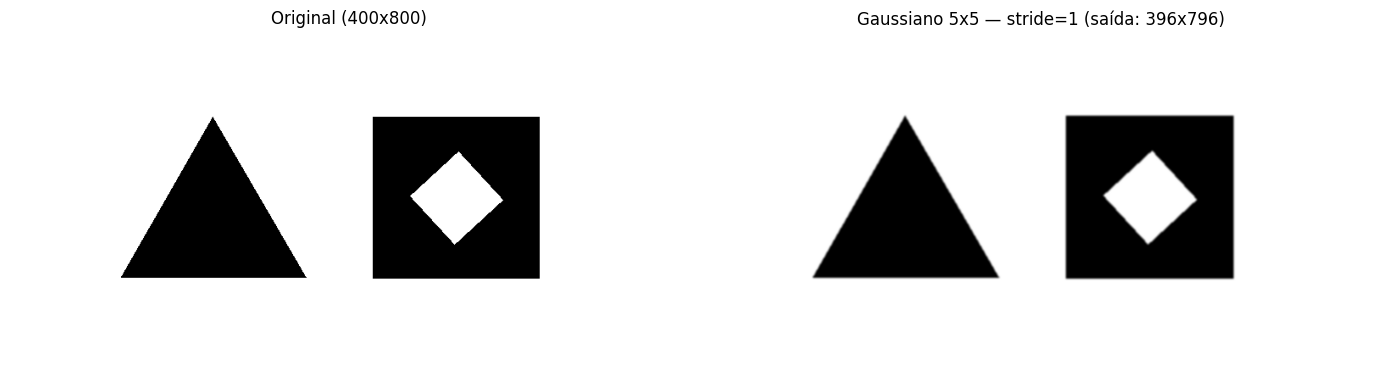

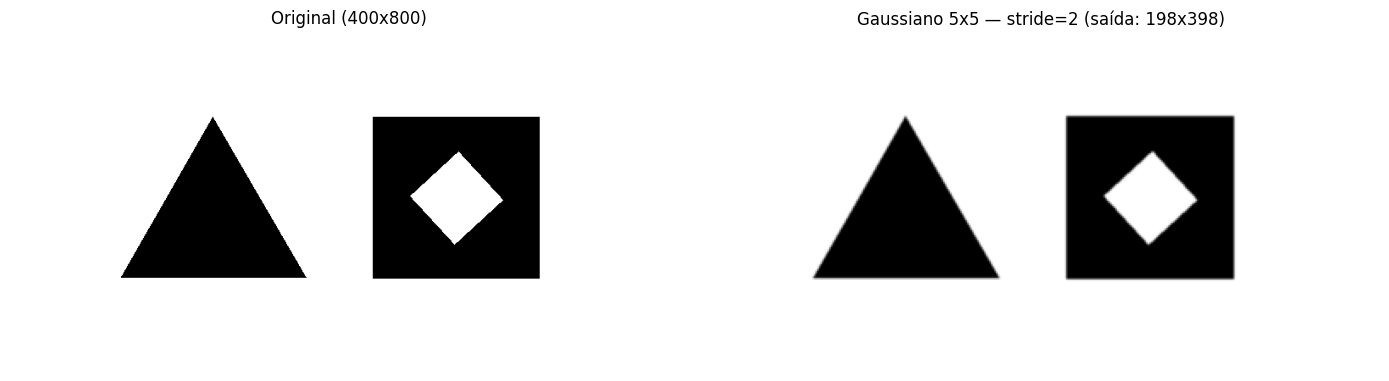

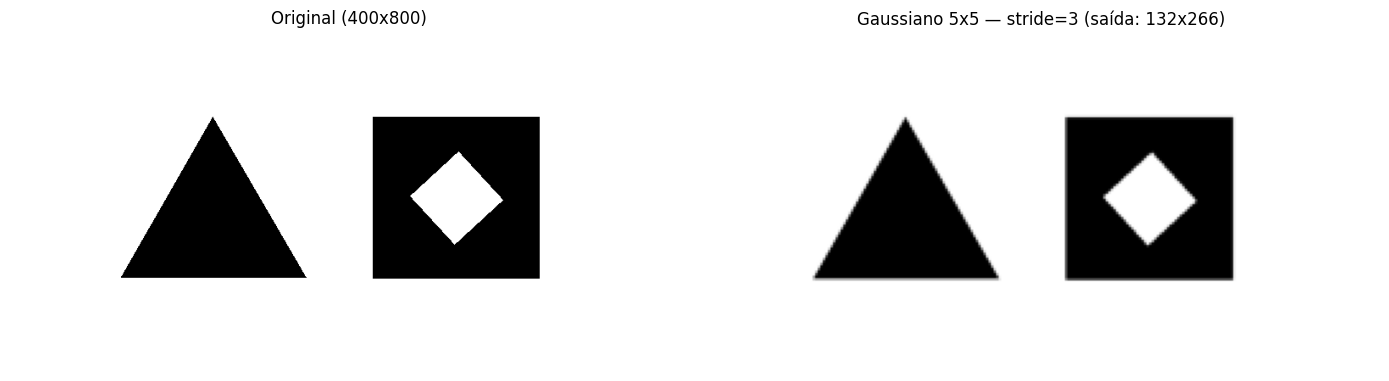

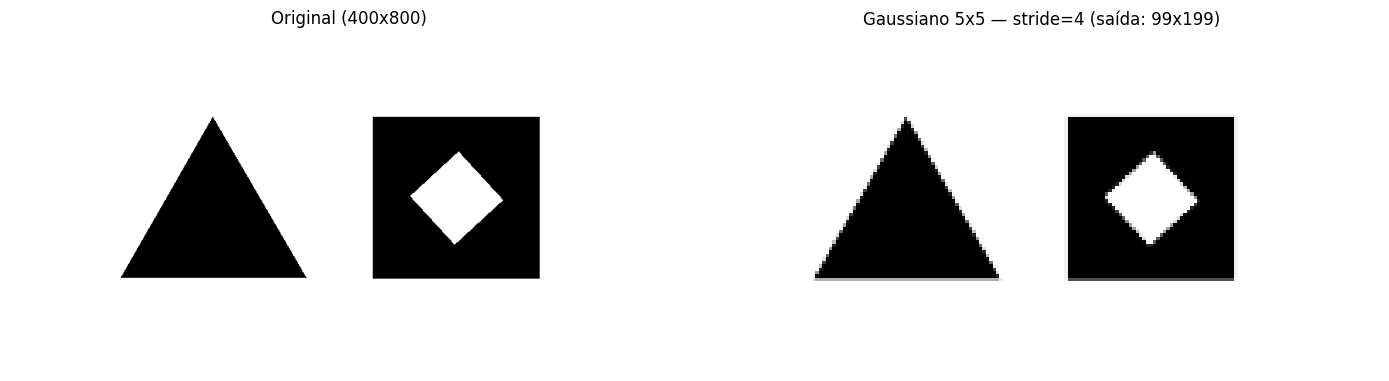

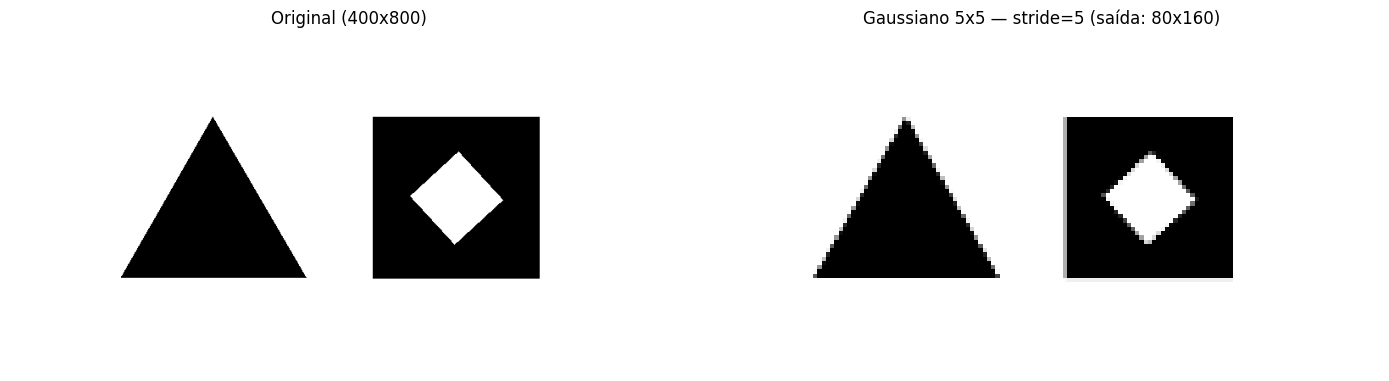

In [30]:
# Efeito da variação do stride com Gaussiano 5x5 na Imagem 1
mascara_gaussiano = gaussiano_5x5()
valores_stride = [1, 2, 3, 4, 5]

for s_val in valores_stride:
    resultado = correlacao(img1, mascara_gaussiano, stride=s_val, r=1)
    resultado = np.clip(resultado, 0, 255).astype(np.uint8)
    
    h_out, w_out = resultado.shape[:2]
    exibir_lado_a_lado(img1, resultado,
        titulo_original=f"Original ({img1.shape[0]}x{img1.shape[1]})",
        titulo_resultado=f"Gaussiano 5x5 — stride={s_val} (saída: {h_out}x{w_out})"
    )

---
## Teste com Função de Ativação ReLU em Sobel

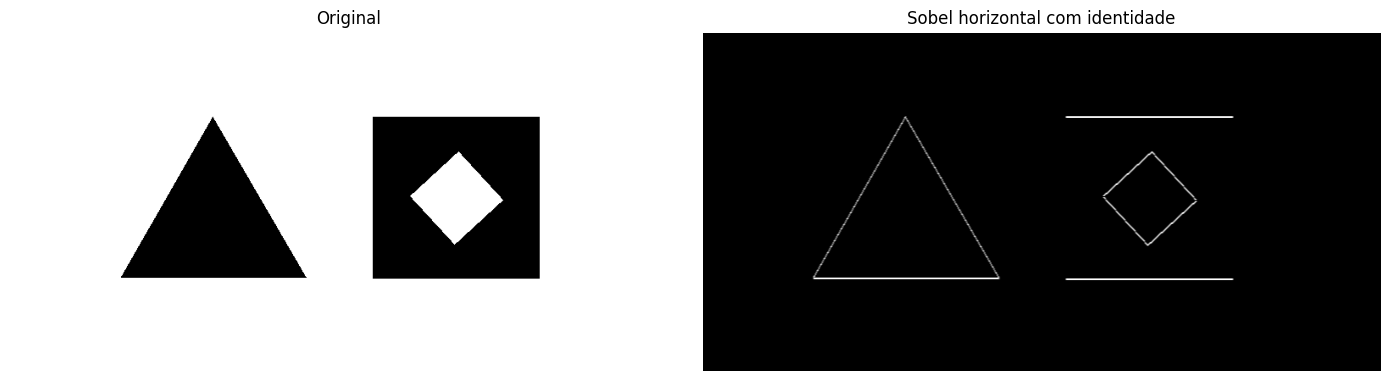

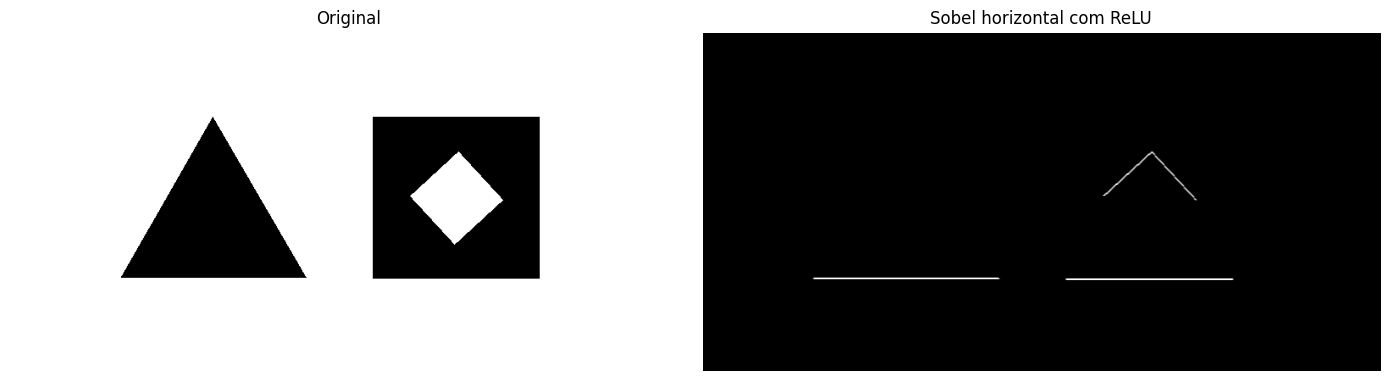

In [31]:
mascara_sh = sobel_horizontal()

# Sobel com Identidade 
res_identidade = correlacao(img1, mascara_sh, stride=1, r=1, ativacao="identidade")
res_identidade_vis = processar_sobel(res_identidade)
exibir_lado_a_lado(img1, res_identidade_vis,
    titulo_original="Original",
    titulo_resultado="Sobel horizontal com identidade"
)

# Sobel com ReLU
res_relu = correlacao(img1, mascara_sh, stride=1, r=1, ativacao="relu")
res_relu_vis = processar_sobel(res_relu)
exibir_lado_a_lado(img1, res_relu_vis,
    titulo_original="Original",
    titulo_resultado="Sobel horizontal com ReLU"
)

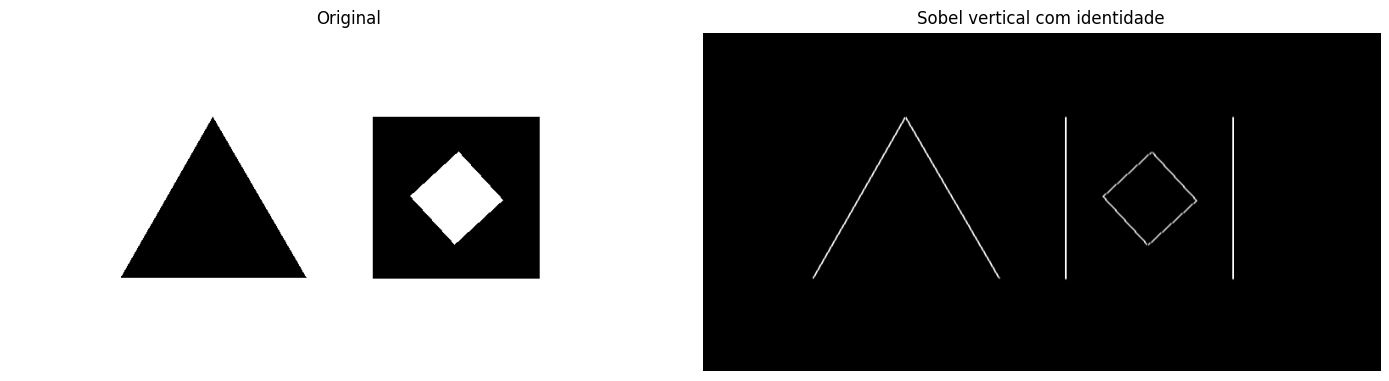

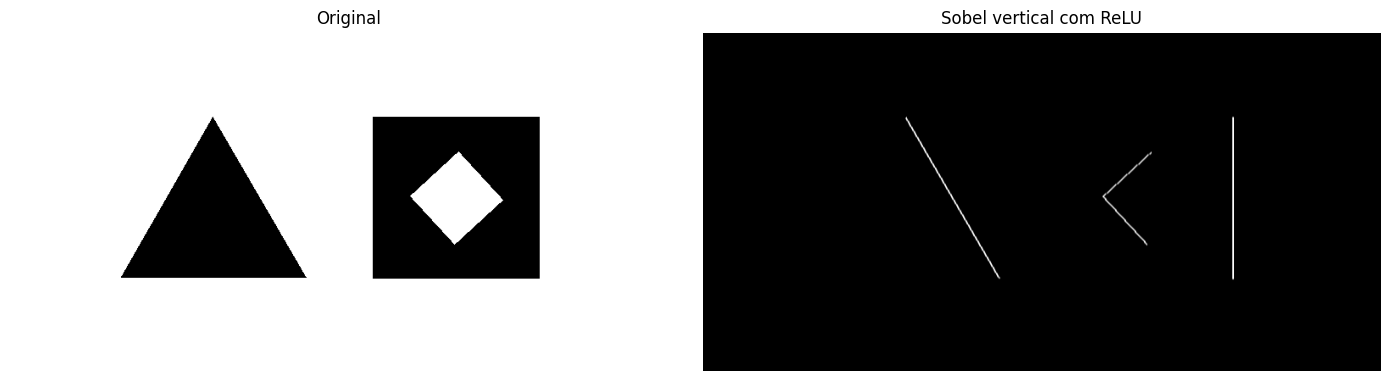

In [32]:
mascara_sv = sobel_vertical()

# Sobel Vertical com Identidade 
res_identidade = correlacao(img1, mascara_sv, stride=1, r=1, ativacao="identidade")
res_identidade_vis = processar_sobel(res_identidade)
exibir_lado_a_lado(img1, res_identidade_vis,
    titulo_original="Original",
    titulo_resultado="Sobel vertical com identidade"
)

# Sobel Vertical com ReLU
res_relu = correlacao(img1, mascara_sv, stride=1, r=1, ativacao="relu")
res_relu_vis = processar_sobel(res_relu)
exibir_lado_a_lado(img1, res_relu_vis,
    titulo_original="Original",
    titulo_resultado="Sobel vertical com ReLU"
)